---
numbering:
  title: false
  headings: false
---

(sec:project_electrolyte_identification)=

# Electrolyte Identification via Conductivity Profiling

## Background

Identifying electrolytes in solution from physical properties requires precise mathematical descriptions of ion transport. This project uses the relationship between concentration ($c$), temperature ($T$), specific conductivity ($\kappa$), and molar conductivity ($\Lambda$). 

Molar conductivity is related to specific conductivity by the equation:

$$\Lambda = \frac{\kappa}{c}$$

To model this behavior across varying concentrations and temperatures, three distinct architectures are evaluated:
* **Kohlrausch Model:** An empirical model valid primarily for strong electrolytes at low concentrations:
   $$\Lambda = \Lambda^0 - K \sqrt{c}$$
* **Polynomial Model:** A flexible baseline implementation mapping local curvature.
* **Lattey Model:** A multi-temperature global framework that models temperature-dependent limiting molar conductivities ($\Lambda^0(T)$) and parameter variations ($A(T)$):
  $$\Lambda = \Lambda^0(T) - A(T) \cdot \frac{\sqrt{m}}{1 + B \cdot \sqrt{m}}$$

Following model optimization and parameter extraction, the Lattey Fit results are used to generate synthetic, noisy conductivity curves. These simulated curves serve as a dataset to run single-electrolyte identification, where a deterministic Mean Squared Error (MSE) template matching strategy and a multiclass One-vs-Rest Support Vector Machine are used.
## Assets

Download the conductivity data here: {download}`/assets/data/projects/conductivity.csv` and {download}`/assets/data/projects/electrolyte_molar_mass.csv`.


* Experimental Data CSV: `conductivity.csv` containing columns for electrolyte names, temperatures, concentrations, and raw $\kappa$ values.
* Molar Mass Metadata CSV: `electrolyte_molar_mass.csv` containing constants for mass-to-molar conversions.

## Implementation

imports

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import random
from sklearn.model_selection import train_test_split
from itertools import combinations

Concentration Conversion Tools

In [79]:
def c_mol_kg_To_c_g_kg(df_M, electrolyte_name, c_mol_kg):
    molar_mass_map = df_M.set_index('Electrolyte')['Molar Mass (g/mol)']
    return c_mol_kg * molar_mass_map[electrolyte_name]

In [80]:
def c_g_kg_To_c_mol_kg(df_M, electrolyte_name, c_g_kg):
    molar_mass_map = df_M.set_index('Electrolyte')['Molar Mass (g/mol)']
    return c_g_kg / molar_mass_map[electrolyte_name]

Kohlrausch Fit Implementation

In [81]:
def kohlrausch_model(sqrt_c, L0, K):
    return L0 - K * sqrt_c

In [82]:
def fit_kohlrausch(df, electrolyte_name, plot=False, print_rmse=False):
    df_sub = df[df['Electrolyte'] == electrolyte_name]
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    temps = sorted(df_sub['T_Celsius'].unique())
    fit_params = {}
    
    if plot:
        plt.figure(figsize=(10, 6))
        colors = plt.cm.viridis(np.linspace(0, 1, len(temps)))
    else:
        colors = [None] * len(temps) 
    
    for t, color in zip(temps, colors):
        slice_df = df_sub[df_sub['T_Celsius'] == t].sort_values('c_mol_kg')
        if not slice_df.empty:
            sqrt_c = np.sqrt(slice_df['c_mol_kg'].values)
            Lambda = slice_df['Lambda'].values

            popt, pcov = curve_fit(kohlrausch_model, sqrt_c, Lambda)
            fit_params[t] = popt
            
            if print_rmse:
                Lambda_pred_kohl = kohlrausch_model(sqrt_c, *popt)
                rmse_kohl = np.sqrt(np.mean((Lambda - Lambda_pred_kohl) ** 2))
                print(f"Kohlrausch RMSE at {t}°C: {rmse_kohl:.4f}")

            if plot:
                plt.scatter(sqrt_c, Lambda, color=color, label=f'Data {t}°C')
                sqrt_c_smooth = np.linspace(sqrt_c.min(), sqrt_c.max(), 200)
                Lambda_fit = kohlrausch_model(sqrt_c_smooth, *popt)
                plt.plot(sqrt_c_smooth, Lambda_fit, color=color, linestyle='-', linewidth=2, zorder=1)
    
    if plot:
        plt.title(f'Kohlrausch Fit for {electrolyte_name} across all temperatures')
        plt.xlabel('sqrt(c)')
        plt.ylabel('Molar Conductivity')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
    return fit_params

In [83]:
def calculate_kohlrausch_rmse(df, electrolyte_name, fit_params):
    df_sub = df[df['Electrolyte'] == electrolyte_name].copy()
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    rmse_results = {}
    for t, popt in fit_params.items():
        slice_df = df_sub[df_sub['T_Celsius'] == t]
        if not slice_df.empty:
            sqrt_c = np.sqrt(slice_df['c_mol_kg'].values)
            Lambda_actual = slice_df['Lambda'].values
            Lambda_predicted = kohlrausch_model(sqrt_c, *popt)
            rmse = np.sqrt(np.mean((Lambda_actual - Lambda_predicted) ** 2))
            rmse_results[t] = rmse
            
    return rmse_results

Polynomial Fit Implementation

In [84]:
def fit_polynomial(df, electrolyte_name, degree=2, plot=False, print_rmse=False):
    df_sub = df[df['Electrolyte'] == electrolyte_name]
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    temps = sorted(df_sub['T_Celsius'].unique())
    fit_params = {}
    
    if plot:
        plt.figure(figsize=(10, 6))
        colors = plt.cm.viridis(np.linspace(0, 1, len(temps)))
    else:
        colors = [None] * len(temps) 

    for t, color in zip(temps, colors):
        slice_df = df_sub[df_sub['T_Celsius'] == t].sort_values('c_mol_kg')
        if not slice_df.empty:
            c = slice_df['c_mol_kg'].values
            Lambda = slice_df['Lambda'].values
            
            beta = np.polyfit(c, Lambda, degree)
            fit_params[t] = beta
            
            if print_rmse:
                Lambda_pred_poly = np.polyval(beta, c)
                rmse_poly = np.sqrt(np.mean((Lambda - Lambda_pred_poly) ** 2))
                print(f"Polynomial RMSE at {t}°C: {rmse_poly:.4f}")

            if plot:
                plt.scatter(c, Lambda, color=color, label=f'Data {t}°C')
                c_smooth = np.linspace(c.min(), c.max(), 200)
                Lambda_fit = np.polyval(beta, c_smooth)
                plt.plot(c_smooth, Lambda_fit, color=color, linestyle='-', linewidth=2, zorder=1)
    
    if plot:
        plt.title(f'Polynomial Fit for {electrolyte_name} across all temperatures')
        plt.xlabel('c')
        plt.ylabel('Molar Conductivity')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return fit_params

In [85]:
def calculate_polynomial_rmse(df, electrolyte_name, fit_params):
    df_sub = df[df['Electrolyte'] == electrolyte_name].copy()
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    rmse_results = {}
    for t, beta in fit_params.items():
        slice_df = df_sub[df_sub['T_Celsius'] == t]
        if not slice_df.empty:
            c = slice_df['c_mol_kg'].values
            Lambda_actual = slice_df['Lambda'].values
            Lambda_predicted = np.polyval(beta, c)
            rmse = np.sqrt(np.mean((Lambda_actual - Lambda_predicted) ** 2))
            rmse_results[t] = rmse
            
    return rmse_results

Lattey Fit (Custom RMSProp Optimization)

In [86]:
def lattey_model(X, a0, a1, a2, l0, l1, l2, B):
    sqrt_m, T = X
    L0_T = l0 + l1 * T + l2 * T**2
    A_T = a0 + a1 * T + a2 * T**2
    return L0_T - A_T * (sqrt_m / (1 + B * sqrt_m))

In [87]:
def lattey_model_scaled(X, a0, a1, a2, l0, l1, l2, B):
    sqrt_m, T = X
    T_scaled = T / 100.0 
    L0_T = l0 + l1 * T_scaled + l2 * T_scaled**2
    A_T = a0 + a1 * T_scaled + a2 * T_scaled**2
    return L0_T - A_T * (sqrt_m / (1 + B * sqrt_m))

In [88]:
def compute_sse(params, X_data, y_data):
    y_pred = lattey_model_scaled(X_data, *params)
    return np.sum((y_pred - y_data) ** 2)

In [89]:
def compute_rmsprop_fit(X_data, y_data, initial_guess, learning_rate=5e-2, iterations=35000):
    params = np.array(initial_guess, dtype=float)
    n_params = len(params)
    h = 1e-5 
    
    grad_sq_avg = np.zeros(n_params)
    beta = 0.99  
    epsilon = 1e-8  
    
    for _ in range(iterations):
        current_ssr = compute_sse(params, X_data, y_data)
        gradient = np.zeros(n_params)
        for i in range(n_params):
            params_tweaked = params.copy()
            params_tweaked[i] += h
            tweaked_ssr = compute_sse(params_tweaked, X_data, y_data)
            gradient[i] = (tweaked_ssr - current_ssr) / h
            
        grad_sq_avg = beta * grad_sq_avg + (1 - beta) * (gradient ** 2)
        adapt_lr = learning_rate / (np.sqrt(grad_sq_avg) + epsilon)
        params -= adapt_lr * gradient
        
        if params[6] < 0:    # Boundary condition constraint: B >= 0
            params[6] = 0.0
        elif params[6] > 15: # Prevent B exploding
            params[6] = 15.0
            
    return params

In [90]:
def fit_lattey_custom(df, electrolyte_name, plot=False, print_rmse=False):
    df_sub = df[df['Electrolyte'] == electrolyte_name].sort_values(['T_Celsius', 'c_mol_kg']).copy()
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    sqrt_m = np.sqrt(df_sub['c_mol_kg'].values)
    T = df_sub['T_Celsius'].values
    X_data = (sqrt_m, T)
    y_data = df_sub['Lambda'].values
    
    guess = [50.0, 10.0, 5.0, 80.0, 150.0, 50.0, 1.0]
    popt = compute_rmsprop_fit(X_data, y_data, initial_guess=guess)
    
    if print_rmse:
        y_pred = lattey_model_scaled(X_data, *popt)
        rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))
        print(f"Lattey Fit (Custom) for {electrolyte_name} - RMSE: {rmse:.4f}")
        
    if plot:
        plt.figure(figsize=(10, 6))
        unique_temps = np.unique(T)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_temps)))
        
        for temp, color in zip(unique_temps, colors):
            mask = (T == temp)
            sm_raw = sqrt_m[mask]
            y_raw = y_data[mask]
            plt.scatter(sm_raw, y_raw, color=color, label=f'Data {temp}°C')
            
            sm_smooth = np.linspace(sm_raw.min(), sm_raw.max(), 200)
            T_smooth = np.full_like(sm_smooth, temp)
            X_smooth = (sm_smooth, T_smooth)
            y_fit = lattey_model_scaled(X_smooth, *popt)
            plt.plot(sm_smooth, y_fit, color=color, linestyle='-', linewidth=2, zorder=1)

        plt.title(f'Lattey Fit for {electrolyte_name} across all temperatures (Custom)')
        plt.xlabel('sqrt(c)')
        plt.ylabel('Molar Conductivity')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return {'a0': popt[0], 'a1': popt[1], 'a2': popt[2], 'l0': popt[3], 'l1': popt[4], 'l2': popt[5], 'B': popt[6]}

Lattey Fit (SciPy Curve Fit Optimizer)

In [91]:
def fit_lattey(df, electrolyte_name, plot=False, print_rmse=False):
    df_sub = df[df['Electrolyte'] == electrolyte_name].sort_values(['T_Celsius', 'c_mol_kg']).copy()
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    sqrt_m = np.sqrt(df_sub['c_mol_kg'].values)
    T = df_sub['T_Celsius'].values
    X_data = (sqrt_m, T)
    y_data = df_sub['Lambda'].values
    
    lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, 0.0]
    upper_bounds = [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]
    
    popt, pcov = curve_fit(lattey_model, X_data, y_data, bounds=(lower_bounds, upper_bounds))
    
    if print_rmse:
        y_pred = lattey_model(X_data, *popt)
        rmse = np.sqrt(np.mean((y_data - y_pred) ** 2))
        print(f"Lattey fit for {electrolyte_name} - Overall RMSE: {rmse:.4f}")
        
    if plot:
        plt.figure(figsize=(10, 6))
        unique_temps = np.unique(T)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_temps)))
        
        for temp, color in zip(unique_temps, colors):
            mask = (T == temp)
            sm_raw = sqrt_m[mask]
            y_raw = y_data[mask]
            plt.scatter(sm_raw, y_raw, color=color, label=f'Data {temp}°C')
            
            sm_smooth = np.linspace(sm_raw.min(), sm_raw.max(), 200)
            T_smooth = np.full_like(sm_smooth, temp)
            X_smooth = (sm_smooth, T_smooth)
            y_fit = lattey_model(X_smooth, *popt)
            plt.plot(sm_smooth, y_fit, color=color, linestyle='-', linewidth=2, zorder=1)
            
        plt.title(f'Lattey Fit for {electrolyte_name} across all temperatures (SciPy)')
        plt.xlabel('sqrt(c)')
        plt.ylabel('Molar Conductivity')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    
    return {'a0': popt[0], 'a1': popt[1], 'a2': popt[2], 'l0': popt[3], 'l1': popt[4], 'l2': popt[5], 'B': popt[6]}

In [92]:
def calculate_lattey_rmse(df, electrolyte_name, fit_params):
    df_sub = df[df['Electrolyte'] == electrolyte_name].copy()
    if df_sub.empty:
        print("ERROR: Electrolyte not found.")
        return None
    
    rmse_results = {}
    temps = sorted(df_sub['T_Celsius'].unique())
    
    for t in temps:
        slice_df = df_sub[df_sub['T_Celsius'] == t]
        if not slice_df.empty:
            sqrt_m = np.sqrt(slice_df['c_mol_kg'].values)
            T_vals = slice_df['T_Celsius'].values
            Lambda_actual = slice_df['Lambda'].values
            X_slice = (sqrt_m, T_vals)
            
            Lambda_predicted = lattey_model(X_slice, 
                                            fit_params['a0'], fit_params['a1'], fit_params['a2'],
                                            fit_params['l0'], fit_params['l1'], fit_params['l2'], 
                                            fit_params['B'])
            
            rmse = np.sqrt(np.mean((Lambda_actual - Lambda_predicted) ** 2))
            rmse_results[t] = rmse
            
    return rmse_results

In [93]:
def get_all_lattey_parameters(df):
    all_params = []
    elec = df['Electrolyte'].unique()
    
    for e in elec:
        p = fit_lattey(df, e, plot=False, print_rmse=False)
        if p is not None:
            p['Electrolyte'] = e
            all_params.append(p)
            
    df_lattey_params = pd.DataFrame(all_params)
    cols = ['Electrolyte', 'a0', 'a1', 'a2', 'l0', 'l1', 'l2', 'B']
    return df_lattey_params[cols]

Synthetic Data Generation

In [94]:
def predict_kappa_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_Celsius = 25):
    row = df_lattey_params[df_lattey_params['Electrolyte'] == electrolyte_name]
    a0, a1, a2 = row['a0'].values[0], row['a1'].values[0], row['a2'].values[0]
    l0, l1, l2 = row['l0'].values[0], row['l1'].values[0], row['l2'].values[0]
    B  = row['B'].values[0]
    
    sqrt_m = np.sqrt(c_mol_kg)
    X = sqrt_m, T_Celsius
    return lattey_model(X, a0, a1, a2, l0, l1, l2, B) * c_mol_kg

In [95]:
def predict_lambda_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_Celsius = 25):
    row = df_lattey_params[df_lattey_params['Electrolyte'] == electrolyte_name]
    if row.empty:
        print("ERROR: Electrolyte not found..")
        return None
    
    a0, a1, a2 = row['a0'].values[0], row['a1'].values[0], row['a2'].values[0]
    l0, l1, l2 = row['l0'].values[0], row['l1'].values[0], row['l2'].values[0]
    B  = row['B'].values[0]
    
    sqrt_m = np.sqrt(c_mol_kg)
    X = sqrt_m, T_Celsius
    return lattey_model(X, a0, a1, a2, l0, l1, l2, B)

In [96]:
def generate_conductivity_curve_c_g(df_lattey_params, df_M, electrolyte_name, model_type = 'kappa', c_g_kg_min = 0.0, c_g_kg_max = 50.0, num_points = 100, T_Celsius = 25.0, noise_level=0.5):
    c_g_kg_range = np.linspace(c_g_kg_min, c_g_kg_max, num_points)
    c_mol_kg_range = c_g_kg_To_c_mol_kg(df_M, electrolyte_name, c_g_kg_range)
    
    model_type_lower = model_type.lower()
    if model_type_lower == 'lambda':
        clean_signal = predict_lambda_lattey(df_lattey_params, electrolyte_name, c_mol_kg_range, T_Celsius)
    elif model_type_lower == 'kappa':
        clean_signal = predict_kappa_lattey(df_lattey_params, electrolyte_name, c_mol_kg_range, T_Celsius)
    else:
        raise ValueError("model_type must be 'lambda' or 'kappa'.")
        
    if clean_signal is None:
        return None, None
        
    if noise_level > 0.0:
        noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
        signal_with_noise = clean_signal + noise
    else:
        signal_with_noise = clean_signal
        
    return c_g_kg_range, signal_with_noise

In [97]:
def generate_conductivity_curve_c_mol(df_lattey_params, electrolyte_name, model_type = 'kappa', c_mol_kg_min = 0.0, c_mol_kg_max = 1.0, num_points = 100, T_Celsius = 25.0, noise_level=0.5):
    c_mol_kg_range = np.linspace(c_mol_kg_min, c_mol_kg_max, num_points)
    model_type_lower = model_type.lower()
    if model_type_lower == 'lambda':
        clean_signal = predict_lambda_lattey(df_lattey_params, electrolyte_name, c_mol_kg_range, T_Celsius)
    elif model_type_lower == 'kappa':
        clean_signal = predict_kappa_lattey(df_lattey_params, electrolyte_name, c_mol_kg_range, T_Celsius)
    else:
        raise ValueError("model_type must be 'lambda' or 'kappa'.")
        
    if clean_signal is None:
        return None, None
        
    if noise_level > 0.0:
        noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
        signal_with_noise = clean_signal + noise
    else:
        signal_with_noise = clean_signal
        
    return c_mol_kg_range, signal_with_noise

In [98]:
def generate_conductivity_curve_T_mol(df_lattey_params, electrolyte_name, model_type = 'kappa', T_min_Celsius = 0.0, T_max_Celsius = 100.0, num_points = 100, c_mol_kg = 0.5, noise_level=0.05):
    T_range = np.linspace(T_min_Celsius, T_max_Celsius, num_points)
    model_type_lower = model_type.lower()
    if model_type_lower == 'lambda':
        clean_signal = predict_lambda_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_range)
    elif model_type_lower == 'kappa':
        clean_signal = predict_kappa_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_range)
    else:
        raise ValueError("model_type must be 'lambda' or 'kappa'.")
        
    if clean_signal is None:
        return None, None
        
    if noise_level > 0.0:
        noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
        signal_with_noise = clean_signal + noise
    else:
        signal_with_noise = clean_signal
        
    return T_range, signal_with_noise

In [99]:
def generate_conductivity_curve_T_g(df_lattey_params, df_M, electrolyte_name, model_type = 'kappa', T_min_Celsius = 0.0, T_max_Celsius = 100.0, num_points = 100, c_g_kg = 0.5, noise_level=0.05):
    T_range = np.linspace(T_min_Celsius, T_max_Celsius, num_points)
    c_mol_kg = c_g_kg_To_c_mol_kg(df_M, electrolyte_name, c_g_kg)
    
    model_type_lower = model_type.lower()
    if model_type_lower == 'lambda':
        clean_signal = predict_lambda_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_range)
    elif model_type_lower == 'kappa':
        clean_signal = predict_kappa_lattey(df_lattey_params, electrolyte_name, c_mol_kg, T_range)
    else:
        raise ValueError("model_type must be 'lambda' or 'kappa'.")
        
    if clean_signal is None:
        return None, None
        
    if noise_level > 0.0:
        noise = np.random.normal(loc=0.0, scale=noise_level, size=num_points)
        signal_with_noise = clean_signal + noise
    else:
        signal_with_noise = clean_signal
        
    return T_range, signal_with_noise

Performance Efficiency Benchmarking

In [100]:
def compare_model_efficiency(df, plot = True):
    comparison_data = []
    unique_electrolytes = df['Electrolyte'].unique()
    
    for e in unique_electrolytes:
        k_params = fit_kohlrausch(df, e)
        l_params = fit_lattey(df, e)
        p_params = fit_polynomial(df, e)
        
        k_rmse_dict = calculate_kohlrausch_rmse(df, e, k_params)
        l_rmse_dict = calculate_lattey_rmse(df, e, l_params)
        p_rmse_dict = calculate_polynomial_rmse(df, e, p_params)
        
        temps = sorted(k_rmse_dict.keys())
        plot_temps, k_rmses, l_rmses, p_rmses = [], [], [], []
        
        for t in temps:
            k_rmse = k_rmse_dict.get(t, np.nan)
            l_rmse = l_rmse_dict.get(t, np.nan)
            p_rmse = p_rmse_dict.get(t, np.nan)
            
            comparison_data.append({
                'Electrolyte': e, 'Temperature_C': t,
                'Kohlrausch_RMSE': k_rmse, 'Lattey_RMSE': l_rmse, 'Polynomial_RMSE': p_rmse,
                'Delta_RMSE_KL': k_rmse - l_rmse, 'Delta_RMSE_KP': k_rmse - p_rmse, 'Delta_RMSE_LP': l_rmse - p_rmse
            })
            
            plot_temps.append(t)
            k_rmses.append(k_rmse)
            l_rmses.append(l_rmse)
            p_rmses.append(p_rmse)
        
        if plot:
            plt.figure(figsize=(9, 4.5))
            plt.plot(plot_temps, k_rmses, marker='o', linewidth=2, color='#e74c3c', label='Kohlrausch (Isolated Fits)')
            plt.plot(plot_temps, p_rmses, marker='.', linewidth=2, linestyle=':', color="#b553d3", label='Polynomial (Isolated Fits)')
            plt.plot(plot_temps, l_rmses, marker='s', linestyle='--', linewidth=2, color='#2ce3a4', label='Lattey (Global Fit)')
            plt.title(f'RMSE Comparison for {e}', fontsize=12, fontweight='bold')
            plt.xlabel('Temperature')
            plt.ylabel('RMSE')
            plt.legend()
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tight_layout()
            plt.show()
        
    return pd.DataFrame(comparison_data)

Data ingestion & execution

In [101]:
df = pd.read_csv('../../assets/data/projects/conductivity.csv')
df_M = pd.read_csv('../../assets/data/projects/electrolyte_molar_mass.csv')
molar_mass_map = df_M.set_index('Electrolyte')['Molar Mass (g/mol)']
df['c_g_kg'] = df['c_mol_kg'] * df['Electrolyte'].map(molar_mass_map)
df['Lambda'] = df['kappa'] / df['c_mol_kg']

df_lattey_results = get_all_lattey_parameters(df)

Optimitation comparision Custom vs Scipy

Lattey Fit (Custom) for KCl - RMSE: 1.9882


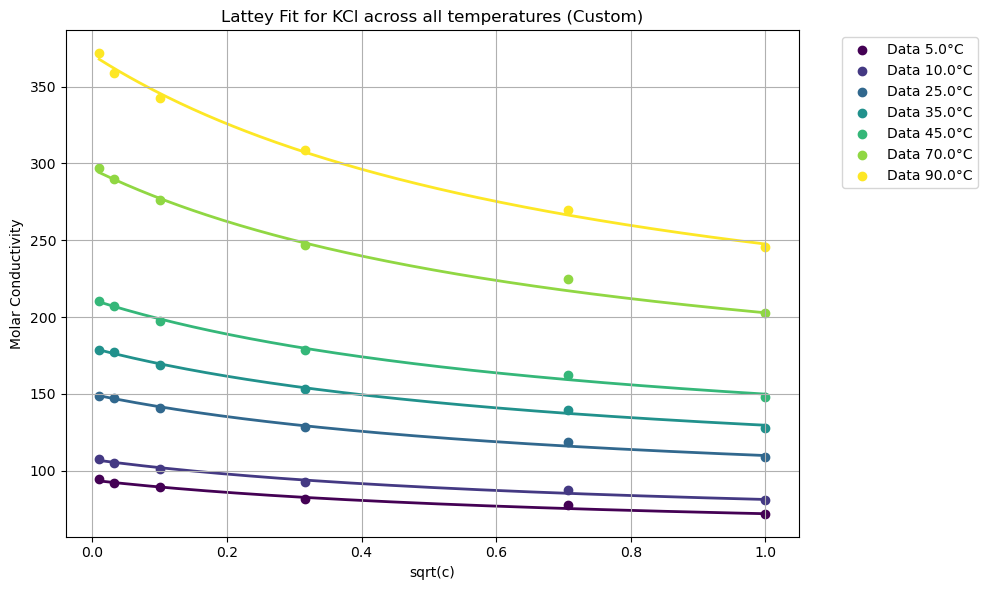

Lattey fit for KCl - Overall RMSE: 1.9443


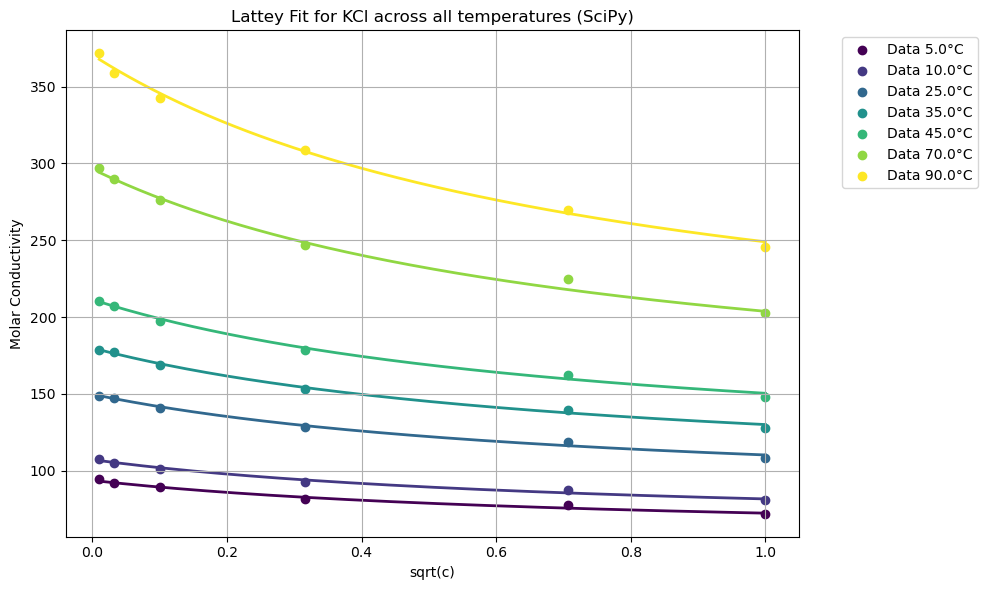

{'a0': np.float64(39.914826766051036),
 'a1': np.float64(1.8077996260132125),
 'a2': np.float64(0.009620121924866004),
 'l0': np.float64(80.56876461044325),
 'l1': np.float64(2.591525368569459),
 'l2': np.float64(0.006997314304886909),
 'B': np.float64(1.3084809154819594)}

In [102]:
fit_lattey_custom(df, 'KCl', plot=True, print_rmse=True)
fit_lattey(df, 'KCl', plot=True, print_rmse=True)

Visual Verification of Curve Fitting 

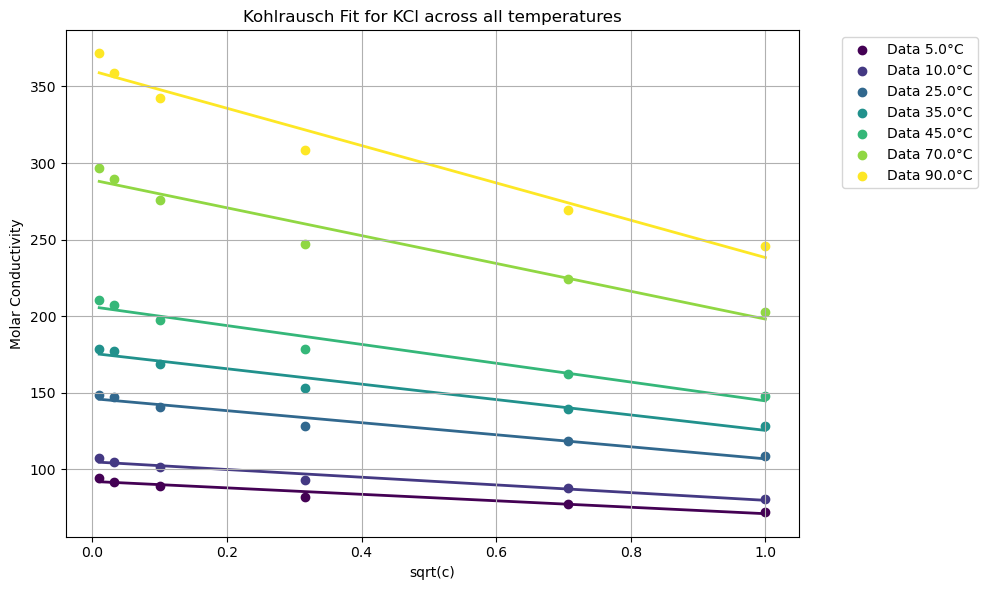

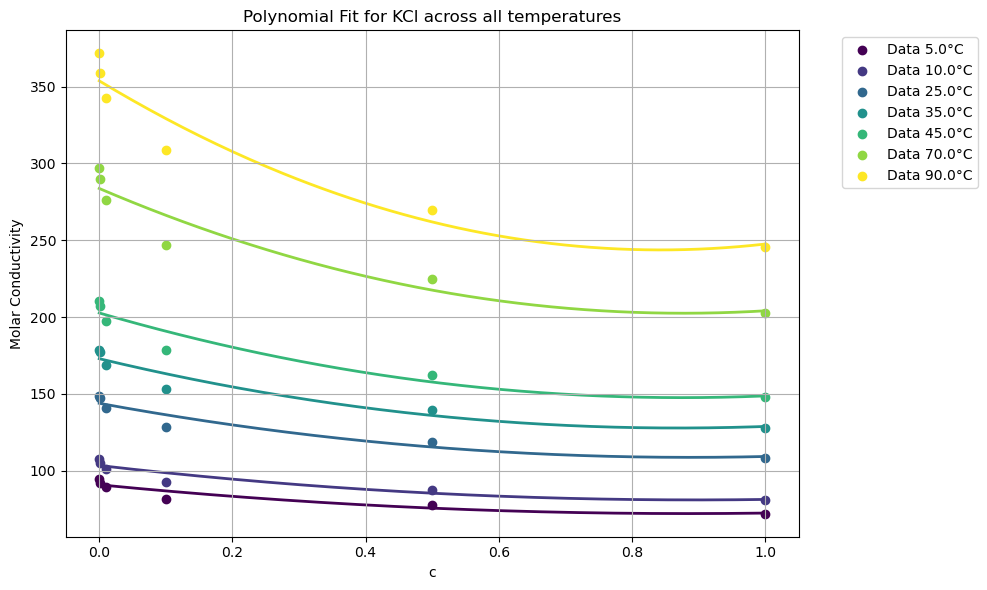

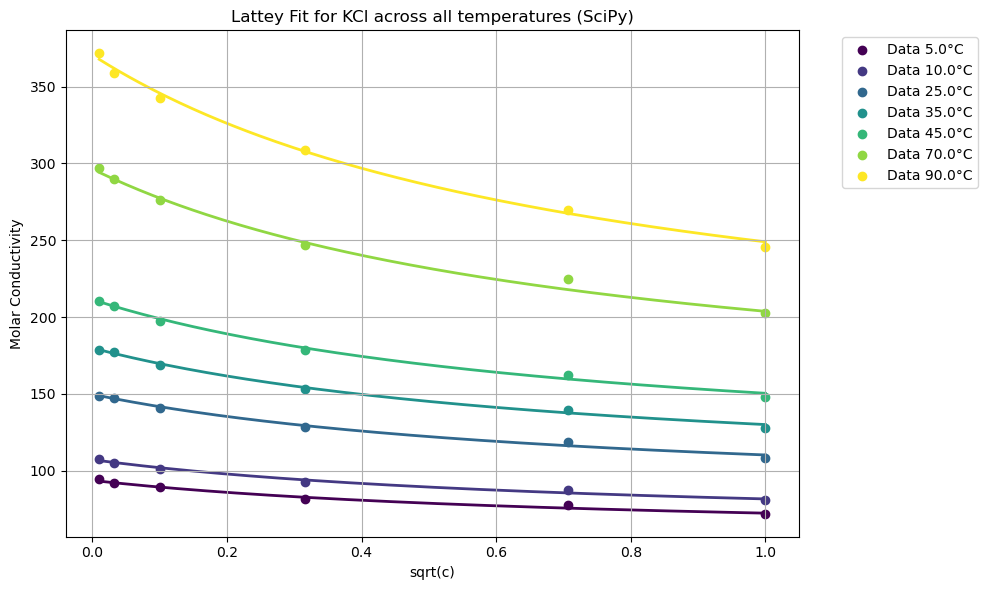

{'a0': np.float64(39.914826766051036),
 'a1': np.float64(1.8077996260132125),
 'a2': np.float64(0.009620121924866004),
 'l0': np.float64(80.56876461044325),
 'l1': np.float64(2.591525368569459),
 'l2': np.float64(0.006997314304886909),
 'B': np.float64(1.3084809154819594)}

In [103]:
elec = 'KCl'
fit_kohlrausch(df, elec, plot=True)
fit_polynomial(df, elec, plot=True)
fit_lattey(df, elec, plot=True)

Benchmarking

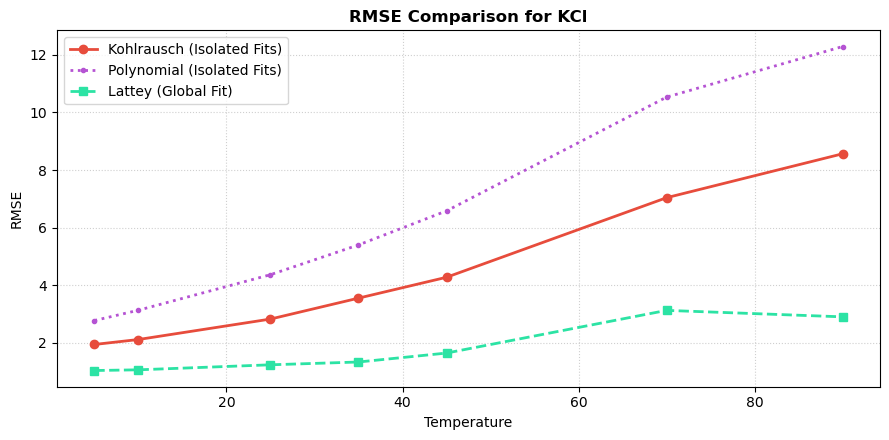

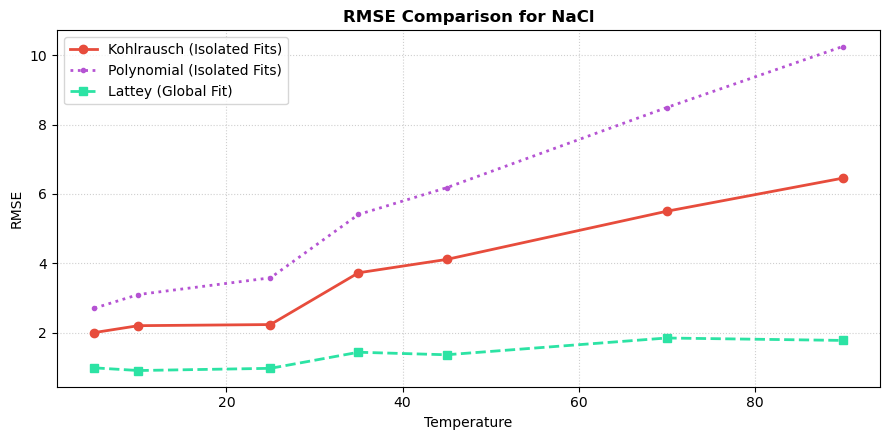

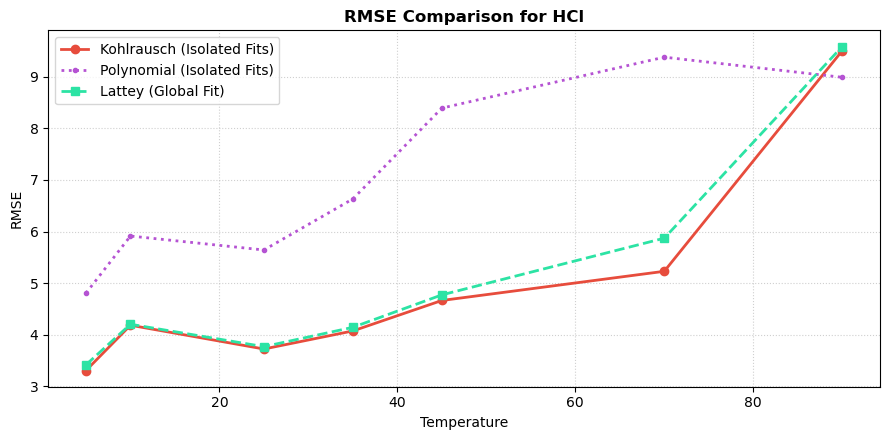

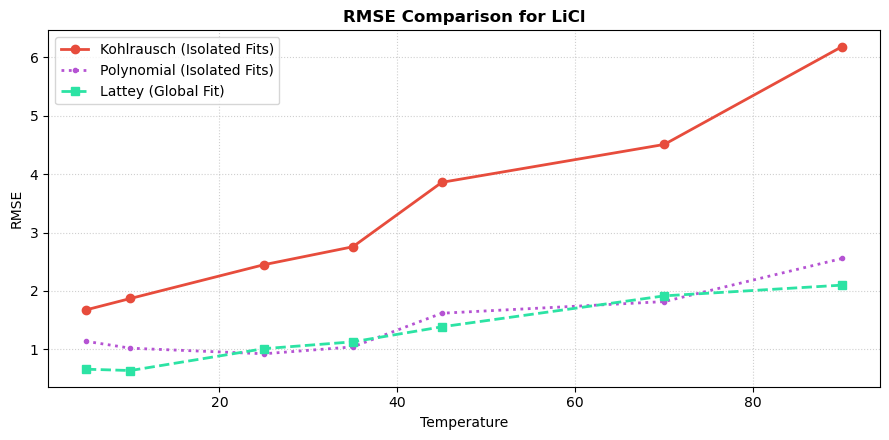

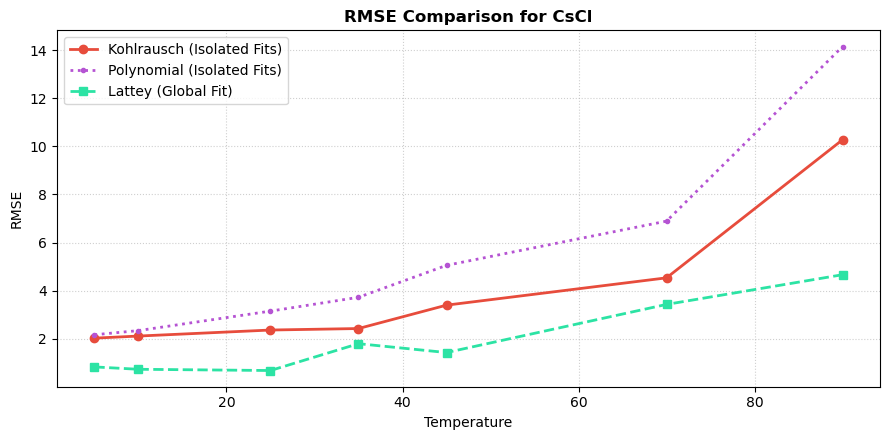

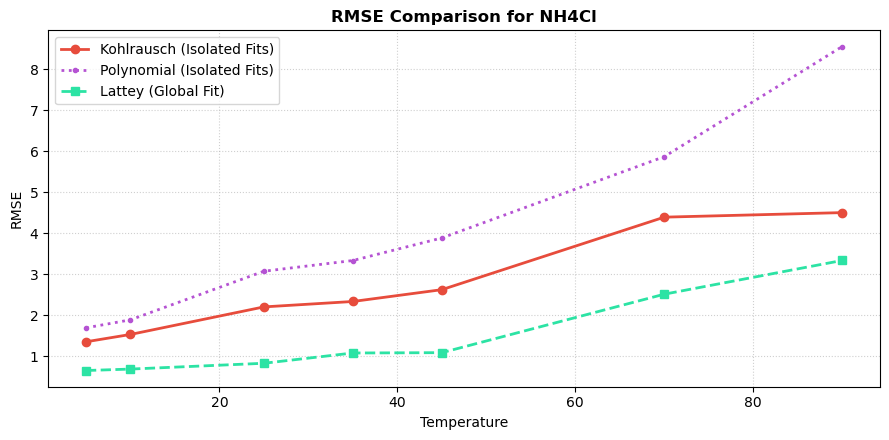

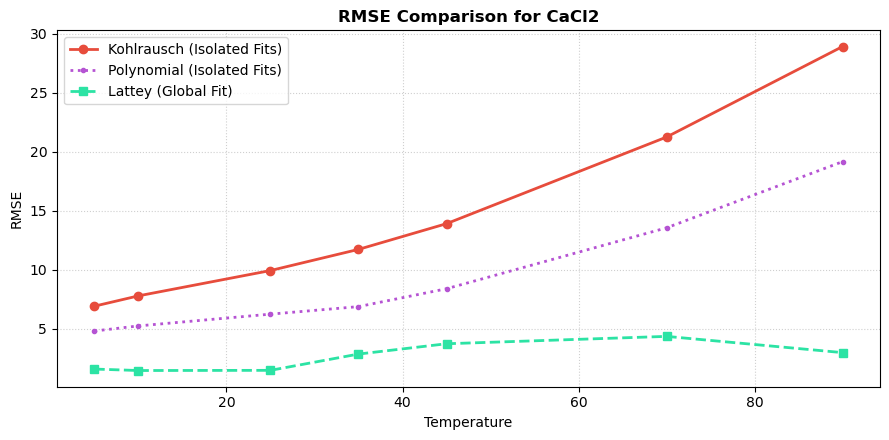

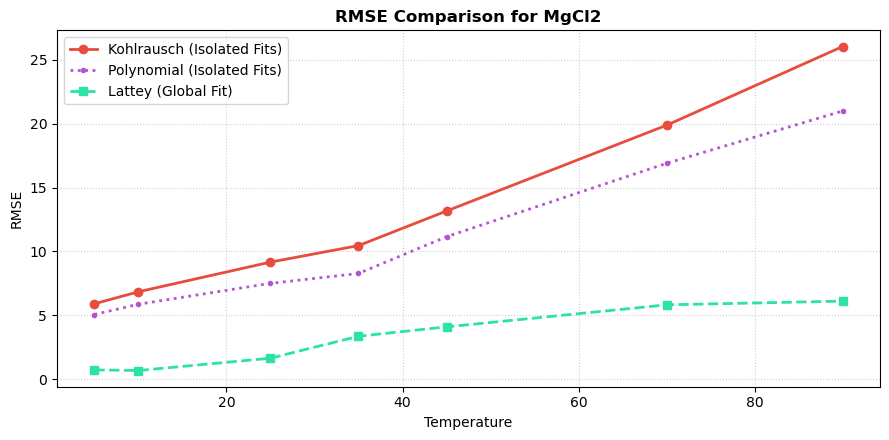

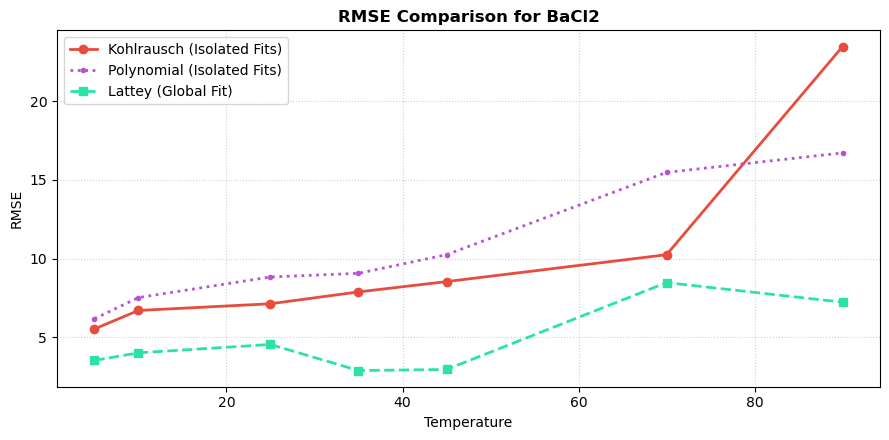

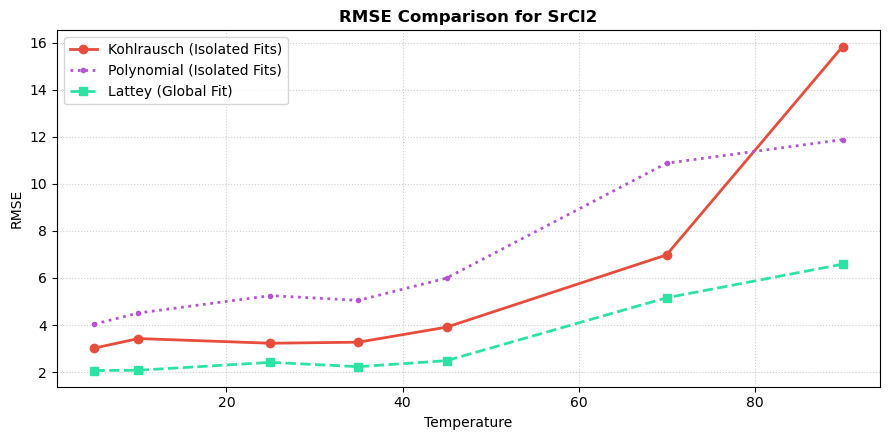

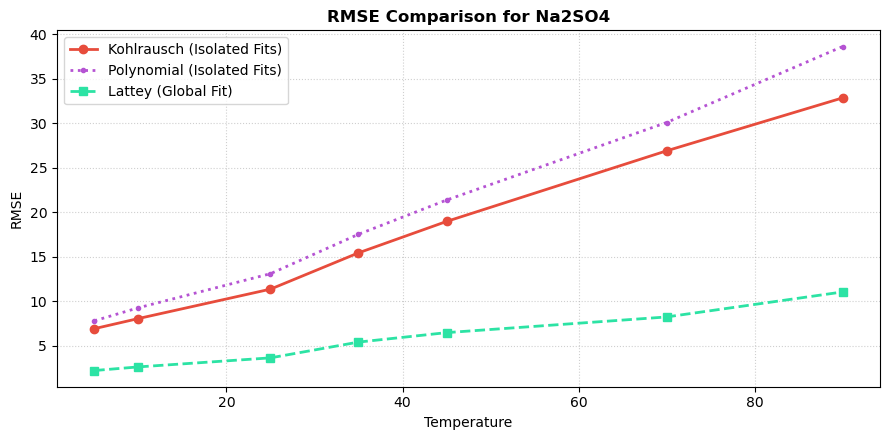

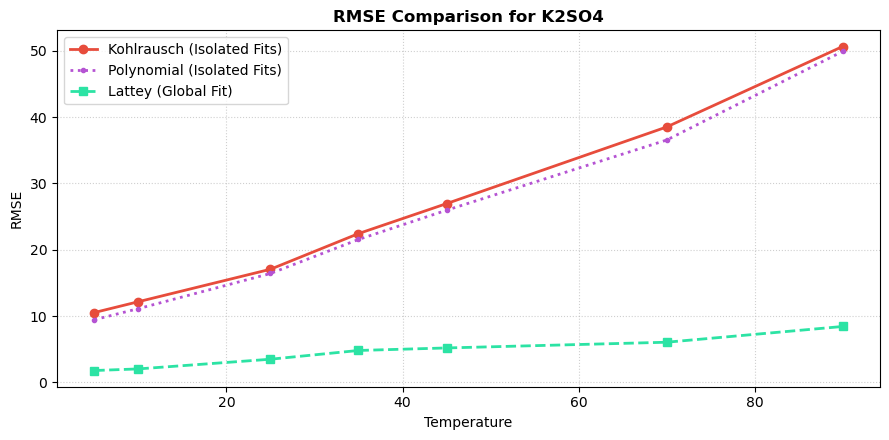

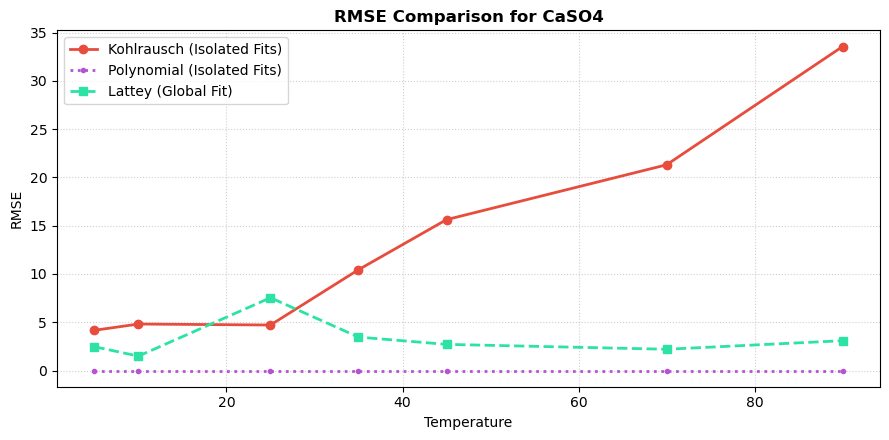

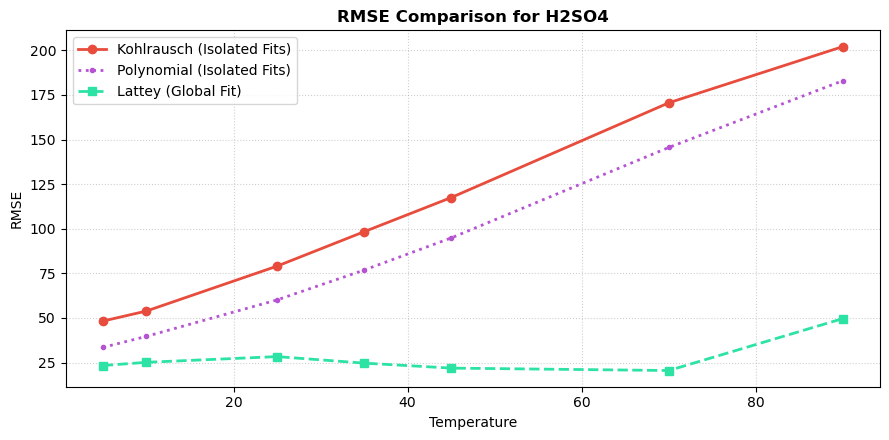

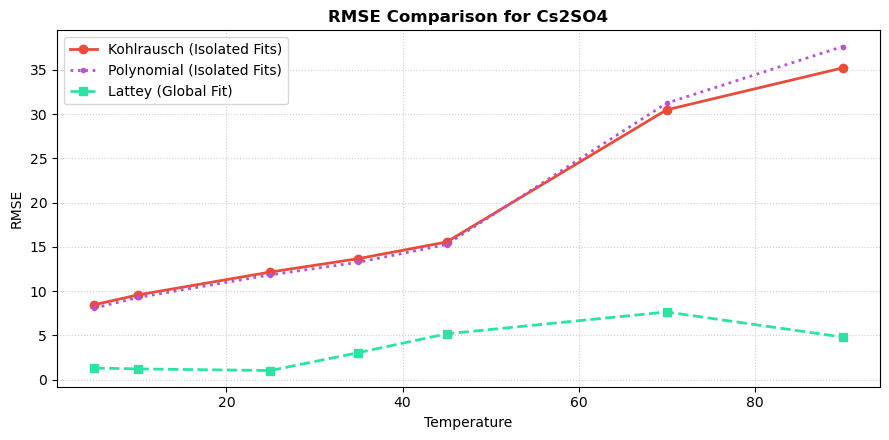

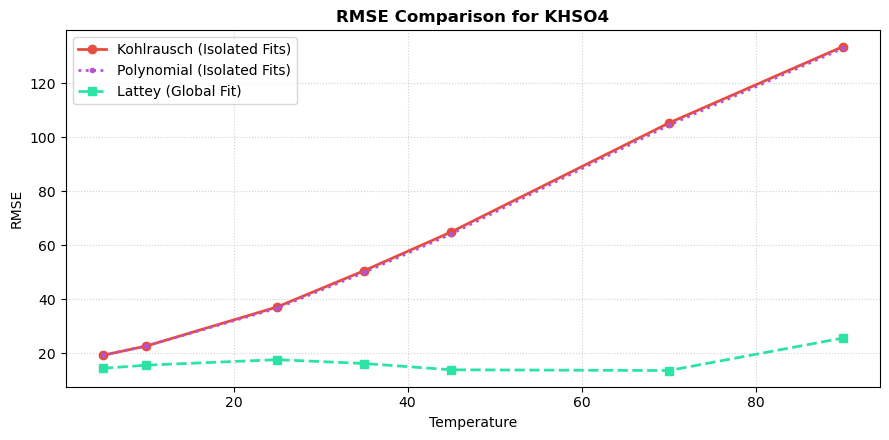

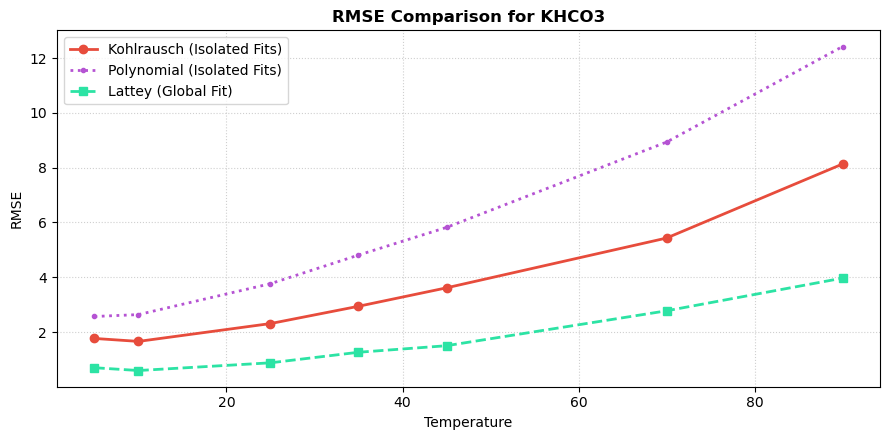

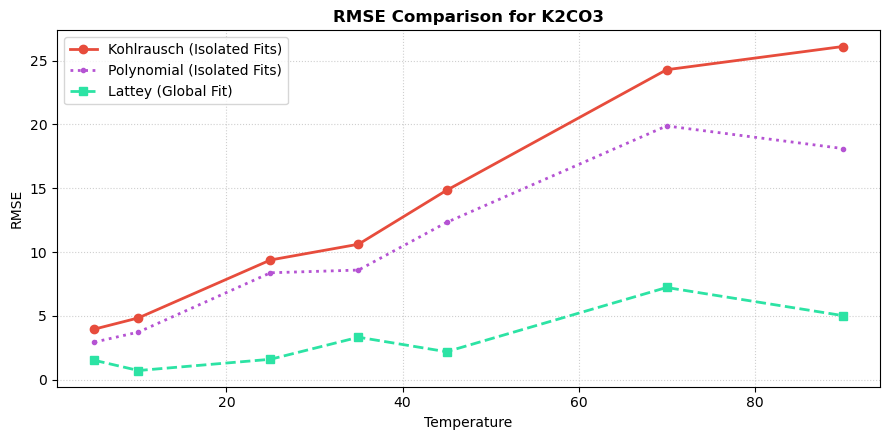

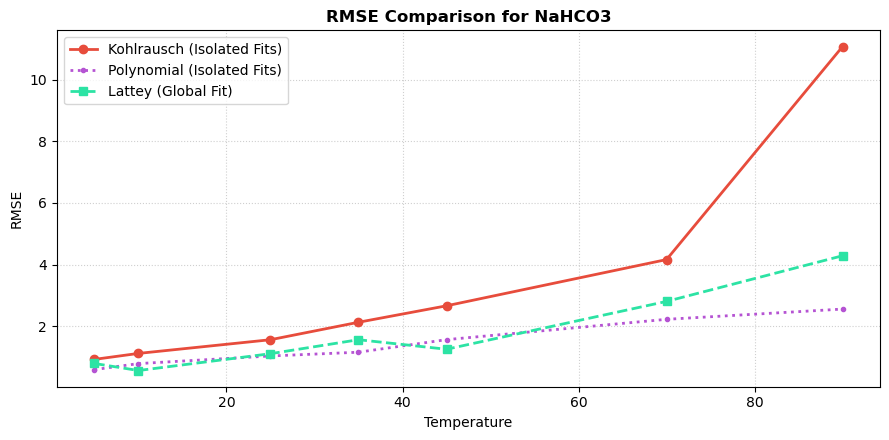

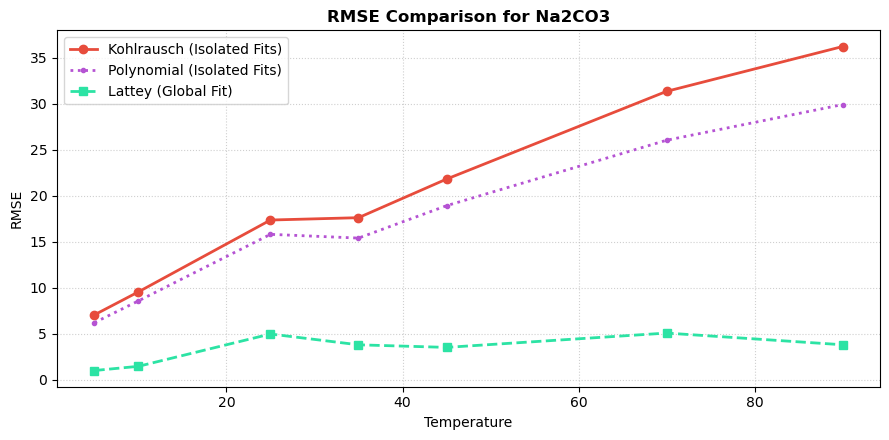

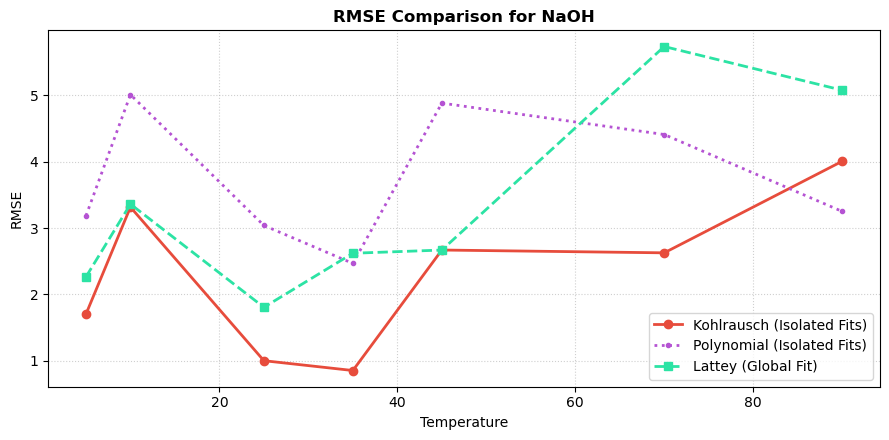

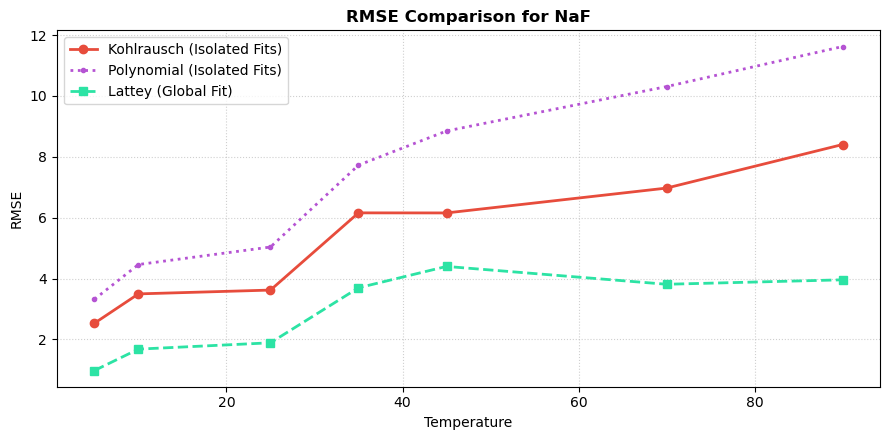

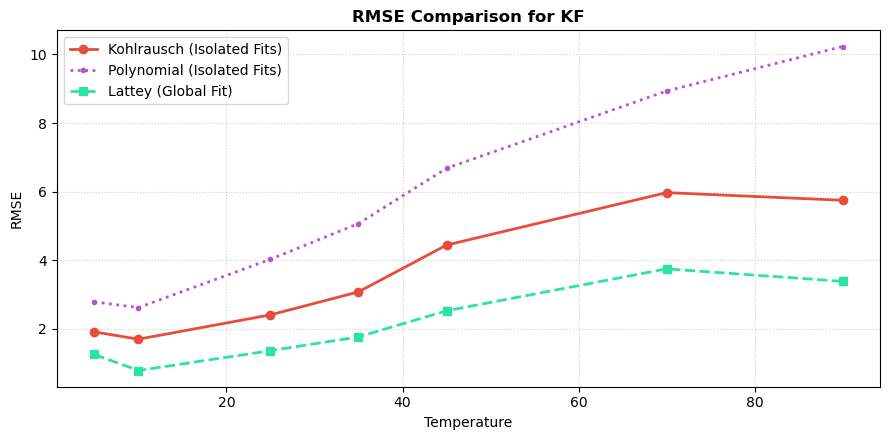

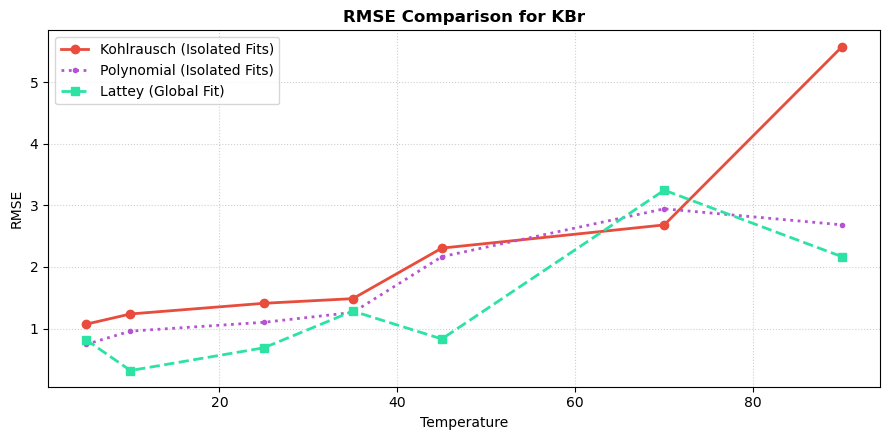

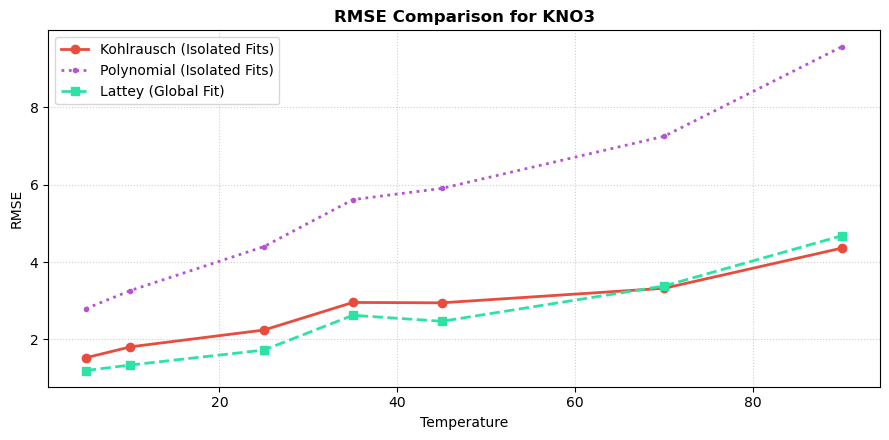

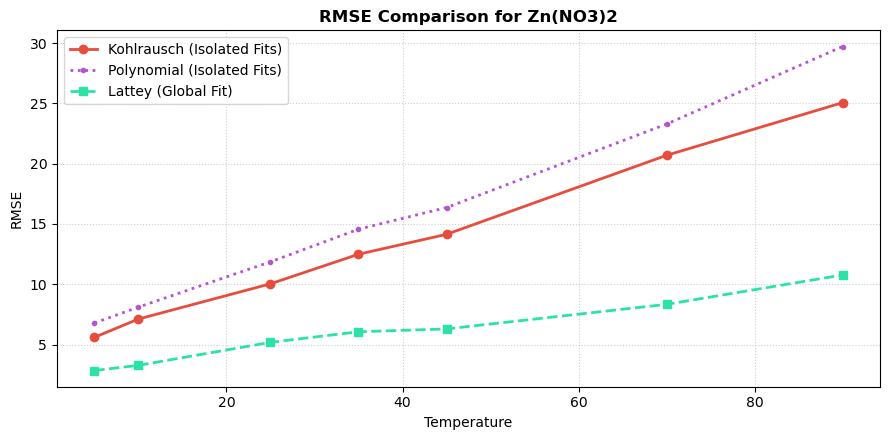

In [104]:
df_comp = compare_model_efficiency(df, True)

Synthetic conductivity curve generation in Mass vs. Molar concentrations

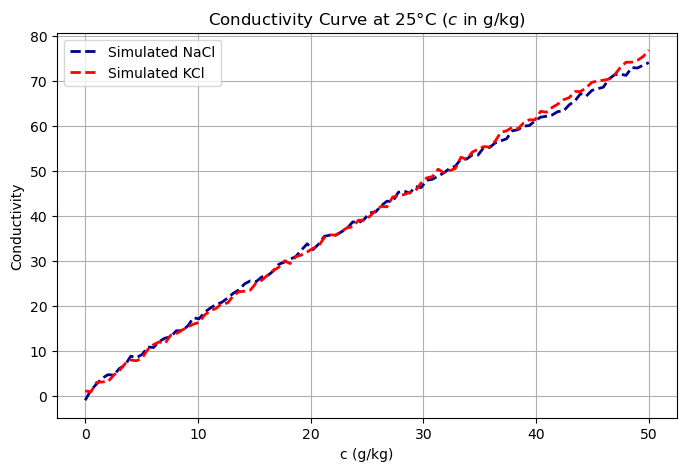

In [105]:
c_sim, lambda_sim = generate_conductivity_curve_c_g(df_lattey_results, df_M, 'NaCl', model_type='kappa')
c_sim2, lambda_sim2 = generate_conductivity_curve_c_g(df_lattey_results, df_M, 'KCl', model_type='kappa')

plt.figure(figsize=(8, 5))
plt.plot(c_sim, lambda_sim, color='darkblue', linestyle='--', linewidth=2, label='Simulated NaCl')
plt.plot(c_sim2, lambda_sim2, color='red', linestyle='--', linewidth=2, label='Simulated KCl')
plt.title('Conductivity Curve at 25°C ($c$ in g/kg)')
plt.xlabel('c (g/kg)')
plt.ylabel('Conductivity')
plt.legend()
plt.grid(True)
plt.show()

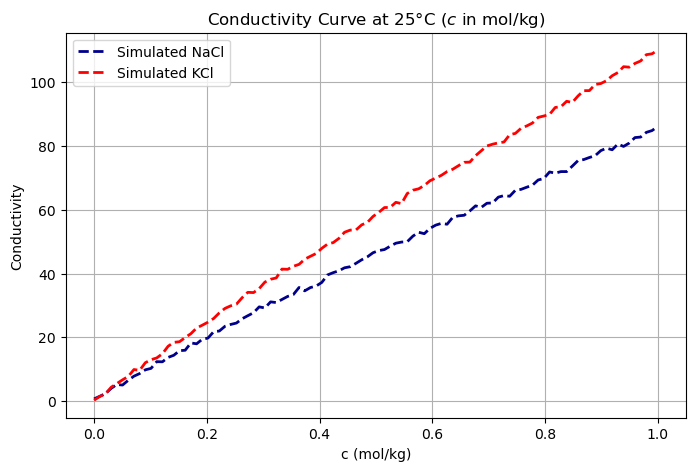

In [106]:
c_sim_mol, lambda_sim_mol = generate_conductivity_curve_c_mol(df_lattey_results, 'NaCl', model_type='kappa')
c_sim_mol2, lambda_sim_mol2 = generate_conductivity_curve_c_mol(df_lattey_results, 'KCl', model_type='kappa')

plt.figure(figsize=(8, 5))
plt.plot(c_sim_mol, lambda_sim_mol, color='darkblue', linestyle='--', linewidth=2, label='Simulated NaCl')
plt.plot(c_sim_mol2, lambda_sim_mol2, color='red', linestyle='--', linewidth=2, label='Simulated KCl')
plt.title('Conductivity Curve at 25°C ($c$ in mol/kg)')
plt.xlabel('c (mol/kg)')
plt.ylabel('Conductivity')
plt.legend()
plt.grid(True)
plt.show()

Gerneration of training data

In [107]:
#Reference curves without noise
names = ['KCl', 'NaCl', 'NH4Cl', 'K2SO4', 'KNO3']
perfect_curves=[]

for electrolyte in names:
    c_sim, perfect_curve = generate_conductivity_curve_c_g(
        df_lattey_results, 
        df_M,
        electrolyte,
        model_type='kappa',
        noise_level=0
        )

    perfect_curve = np.maximum(perfect_curve, 0)
    perfect_curves.append(perfect_curve)
perfect_curves = np.array(perfect_curves)
print(perfect_curves.shape)

#noisy training data
X = []
y = []

for electrolyte in names:
    
    for j in range(100):
        c_sim, measured_curve = generate_conductivity_curve_c_g(
            df_lattey_results,
            df_M,
            electrolyte,
            model_type="kappa",
            noise_level=1.2
        )

        measured_curve = np.maximum(measured_curve, 0)

        X.append(measured_curve)
        y.append(electrolyte)


X = np.array(X)
y = np.array(y)

#print(X)
#print(X.shape)
#print(y.shape)
#print(y)

(5, 100)


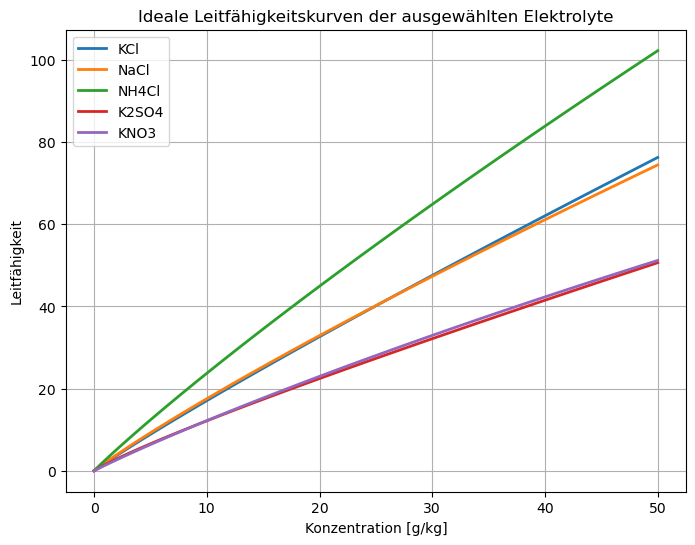

In [108]:
# plotted reference conductivity curves (without noise) of the chosen electrolytes

plt.figure(figsize=(8,6))

for i, electrolyte in enumerate(names):
    plt.plot(c_sim, perfect_curves[i], linewidth=2, label=electrolyte)

plt.xlabel("Konzentration [g/kg]")
plt.ylabel("Leitfähigkeit")
plt.title("Ideale Leitfähigkeitskurven der ausgewählten Elektrolyte")
plt.legend()
plt.grid(True)

plt.show()

Classification Strategy 1: Determination via Mean Squared Error (MSE)

In [109]:
def mse(curve1, curve2):
    return np.mean((curve1-curve2)**2)

In [110]:
#picking random electrolyte curve
index = np.random.randint(len(X))

#determining mse regarding the perfect_curves
mse_electrolyte = []
for i in range(len(names)):
    mse_value = mse(perfect_curves[i], X[index])
    mse_electrolyte.append(mse_value)

mse_electrolyte = np.array(mse_electrolyte)

print(mse_electrolyte)

# Automatically determine the best match
best = np.argmin(mse_electrolyte)

print('prediction: the unknown electrolyte is:', names[best])
print('actually it was:', y[index])

[262.89849447 279.75867008   1.30312163 961.90433765 927.00594297]
prediction: the unknown electrolyte is: NH4Cl
actually it was: NH4Cl


Global accuracy

In [111]:
correct = 0

for index in range(len(X)):
    mse_electrolyte = []
    for i in range(len(names)):
        mse_value = mse(perfect_curves[i], X[index])
        mse_electrolyte.append(mse_value)

    mse_electrolyte = np.array(mse_electrolyte)
    
    prediction = names[np.argmin(mse_electrolyte)]

    if prediction == y[index]:
        correct += 1
    else: print("Wahr:", y[index],"| Vorhersage:", prediction)

accuracy = correct / len(X)
print(accuracy)

1.0


Classification Strategy 2: Support Vector Machine (SVM)

This model optimizes a decision hyperplane using a hinge-loss objective function coupled with an $L_2$ regularization penalty ($\lambda$) optimized via Stochastic Gradient Descent.

In [112]:
class SupportVectorMachine:
    def __init__(self, dim=2, alpha=0.1, n_epochs=100, lam=0.1):
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.lam = lam
        self.beta = np.random.randn(dim+1)
    def net_input(self, x):
        return x @ self.beta
    def fit(self, X, y):
        N = len(X)
        for _ in range(self.n_epochs):
            for xi, yi in zip(X, y):
                update = yi if yi * self.net_input(xi) < 1.0 else 0.0
                self.beta += self.alpha * (update * xi / N - self.lam * self.beta)
        return self
    def predict(self, x):
        return np.where(self.net_input(x) >= 0.0, 1, -1)
    def decision_function(self,x):
        return self.net_input(x)

Bias Addition

In [113]:
print(X.shape)
print(len(X[0]))

# add bias column
bias = np.ones((len(X), 1))
X_bias = np.hstack((bias, X))

print(X.shape)
print(X_bias.shape)

(500, 100)
100
(500, 100)
(500, 101)


Spliting Dataset in Training and Testing data

In [114]:
# random order
indices = np.random.permutation(len(X_bias))

# 80 % training
split = int(0.8 * len(X_bias))

train_idx = indices[:split]
test_idx = indices[split:]

# split the data
X_train = X_bias[train_idx]
X_test = X_bias[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print(X_train.shape)
print(X_test.shape)

(400, 101)
(100, 101)


One-vs-Rest Decomposition

Because the primary SVM formulation is binary, we wrap it in a One-vs-Rest ensemble to handle our multiclass electrolyte problem. For each electrolyte a unique SVM is trained to distinguish the target electrolyte ($+1$) from all other species ($-1$).

In [115]:
# One-vs-Rest-SVM
models = []
for electrolyte in names:
    y_train_binary = np.where(y_train == electrolyte, 1, -1)

    svm = SupportVectorMachine(
        dim=100,
        alpha=0.001,
        n_epochs=1000,
        lam=0.01
    )
    svm.fit(X_train, y_train_binary)

    models.append(svm)

Isolated Binary Model Evaluation

In [116]:
for i in range(len(names)):

    y_test_binary  = np.where(y_test  == names[i], 1, -1)
   
    prediction = models[i].predict(X_test)

    accuracy = np.mean(prediction == y_test_binary)

    print(names[i], accuracy)

KCl 0.94
NaCl 0.85
NH4Cl 0.8
K2SO4 0.71
KNO3 0.84


Accuracy of Multiclass One-vs-Rest prediction through Margin confidence

The global prediction for an unknown sample is generated by querying all binary models. The unknown vector is evaluated across all `decision_function` margins. The final classification label is assigned to the model yielding the highest positive score (highest margin confidence).

In [117]:
# Calculate accuracy (with all test data)
correct = 0

for i in range(len(X_test)):
    unknown = X_test[i]
    scores = []

    for svm in models:
        score = svm.decision_function(unknown)
        scores.append(score)
    
    best = np.argmax(scores)
    prediction = names[best]
    if prediction == y_test[i]:
        correct += 1

accuracy = correct / len(X_test)
print('Accuracy =', accuracy)  

Accuracy = 0.26


In [118]:
# Confusion matrix

confusion = np.zeros((len(names), len(names)), dtype=int)

for i in range(len(X_test)):

    unknown = X_test[i]

    scores = []

    for svm in models:
        scores.append(svm.decision_function(unknown))

    prediction = np.argmax(scores)

    true = names.index(y_test[i])
    
    confusion[true, prediction] += 1

print(confusion)

[[20  0  0  0  0]
 [10  0  4  0  1]
 [20  0  0  0  0]
 [17  0  9  3  0]
 [ 6  0  5  2  3]]


Choosing electrolytes for mixture analysis

In [ ]:
# generating one-component curves with noise
electrolyte_list_all = ['KCl', 'NaCl', 'HCl', 'LiCl', 'CsCl', 'NH4Cl', 'CaCl2', 'MgCl2', 
                        'BaCl2', 'SrCl2', 'Na2SO4', 'K2SO4', 'CaSO4', 'H2SO4', 'Cs2SO4', 'KHSO4', 
                        'KHCO3', 'K2CO3', 'NaHCO3', 'Na2CO3', 'NaOH', 'NaF', 'KF', 'KBr', 'KNO3', 'Zn(NO3)2']
electrolyte_list = ['KCl', 'LiCl', 'CsCl', 'NH4Cl', 'CaCl2', 'MgCl2', 'Na2SO4', 'CaSO4', 
                            'NaHCO3','K2CO3', 'KNO3', 'Zn(NO3)2', 'KBr']
reference_curves = []
for electrolyte in electrolyte_list_all:
    m_, curve_ = generate_conductivity_curve_c_g(df_lattey_results, df_M, electrolyte, model_type='kappa')
    reference_curves.append({
        "Component": electrolyte,
        "Kappa": curve_
    })
reference_curves = np.array(reference_curves)

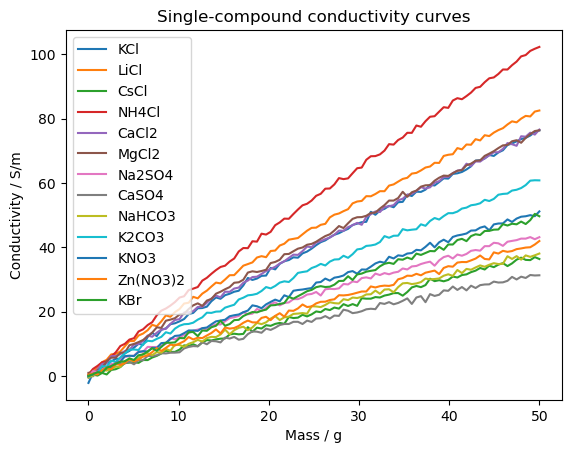

In [120]:
# plotting all conductivity curves at once 
for i in electrolyte_list:
    for ref in reference_curves:
        if ref["Component"] == i:
            plt.plot(m_, ref["Kappa"], label=ref["Component"])
plt.title('Single-compound conductivity curves')
plt.xlabel('Mass / g')
plt.ylabel('Conductivity / S/m')
plt.legend()
plt.show()

Generating 50 random mixtures of 2 compounds as well as one-compound reference curves

In [121]:
mixtures = []
for _ in range(50):
    compound1, compound2 = random.sample(electrolyte_list, 2)

    w1 = round(np.random.uniform(0.2, 0.8), 2)
    w2 = round(1 - w1, 2)

    m1, kappa_1 = generate_conductivity_curve_c_g(df_lattey_results, df_M, compound1, model_type='kappa')
    m2, kappa_2 = generate_conductivity_curve_c_g(df_lattey_results, df_M, compound2, model_type='kappa')     
    if np.array_equal(m1, m2):
        m = m1
    kappa_mix_selected = w1 * kappa_1 + w2 * kappa_2

    mixtures.append({
        "Components": [compound1, compound2],
        "Weights": [w1, w2],
        "Kappa_mix": kappa_mix_selected
            })

['LiCl', 'CaCl2']


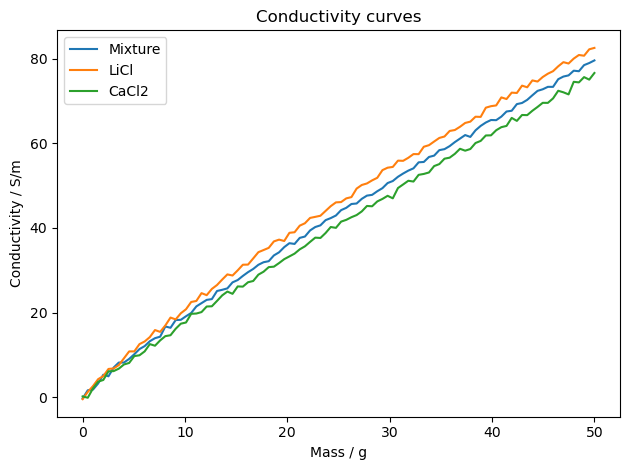

In [122]:
# example of how the curves look like
sample = mixtures[0]
print(sample['Components'])

plt.plot(m, sample["Kappa_mix"], label='Mixture')
for i in sample["Components"]:
    for ref in reference_curves:
        if ref["Component"] == i:
            kappa = ref["Kappa"]
            plt.plot(m, kappa, label=i)
plt.xlabel('Mass / g')
plt.ylabel('Conductivity / S/m')
plt.title('Conductivity curves')
plt.tight_layout()
plt.legend()
plt.show()

Building PCA

In [123]:
class PCA:
    def __init__(self, k):
        self.k = k
        self.components = None
        self.mean = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        covariance_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
        self.components = eigenvectors[:, :: -1][:, :self.k]
        self.explained_variance = eigenvalues[::-1] / np.sum(eigenvalues)
        return self

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [124]:
# splitting the data to train and test
mixtures_train, mixtures_test = train_test_split(
    mixtures,
    test_size=0.2,
    random_state=42,
)
X_train = np.array([sample['Kappa_mix'] for sample in mixtures_train])
X_test = np.array([sample['Kappa_mix'] for sample in mixtures_test])
print(X_train.shape)
print(X_test.shape)

(40, 100)
(10, 100)


In [125]:
# test how many components are needed
for k in [2, 3, 5, 10, 15, 20]:
    pca = PCA(k=k)
    Z = pca.fit_transform(X_train)
    print(k, np.sum(pca.explained_variance[:k]))

2 0.9985130992690672
3 0.9986086641841483
5 0.9987766316014633
10 0.9991287156201734
15 0.9994004063712889
20 0.9996070310296166


In [126]:
# fit PCA
pca_kappa_mix = PCA(k=2)
Z_mix_train = pca_kappa_mix.fit_transform(X_train)
Z_mix_test = pca_kappa_mix.transform(X_test)
print(Z_mix_train.shape)
print(Z_mix_test.shape)

(40, 2)
(10, 2)


(26, 2)


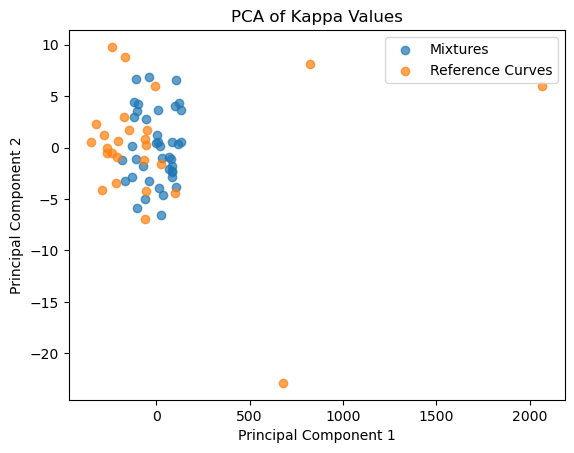

In [127]:
# PCA on reference single-substance curves
X_ref = np.array([ref["Kappa"] for ref in reference_curves])
pca_kappa_ref = PCA(k=2)
Z_pca_ref = pca_kappa_ref.fit_transform(X_ref)
print(Z_pca_ref.shape)

# plot PCA
plt.scatter(Z_mix_train[:, 0], Z_mix_train[:, 1], label='Mixtures', alpha=0.7)
plt.scatter(Z_pca_ref[:, 0], Z_pca_ref[:, 1], label='Reference Curves', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Kappa Values')
plt.legend()
plt.show()

In [128]:
def identify_mixture(unknown_curve, use_pca=False):
    best_error = np.inf
    best_weights = None
    best_pair = None
    if use_pca:
        unknown_pca = pca_kappa_mix.transform(unknown_curve.reshape(1, -1))

    for comp1, comp2 in combinations(electrolyte_list, 2):
        _, curve1 = generate_conductivity_curve_c_g(df_lattey_results, df_M, comp1, model_type='kappa', noise_level=0.0)
        _, curve2 = generate_conductivity_curve_c_g(df_lattey_results, df_M, comp2, model_type='kappa', noise_level=0.0)

        weights = np.linspace(0.2, 0.8, 51)
        for w in weights:
            candidate = w * curve1 + (1 - w) * curve2
            error = mse(candidate, unknown["Kappa_mix"])

            if use_pca:
                candidate_pca = pca_kappa_mix.transform(candidate.reshape(1, -1))
                #candidate_pca_scaled = (candidate_pca - pca_mean) / pca_std
                error = mse(candidate_pca, unknown_pca)

            else:
                error = mse(candidate, unknown_curve)

            if error < best_error:
                best_error = error
                best_pair = (comp1, comp2)
                best_weights = (w, 1 - w)
    return best_pair, best_weights, best_error

Calculate accuracy: PCA vs. without PCA

In [129]:
correct = 0
correct_pca = 0

for unknown in mixtures_test:
    
    # without PCA
    pred_pair, w, error = identify_mixture(unknown['Kappa_mix'], use_pca=False)

    # with PCA
    pred_pair_pca, w_pca, error_pca = identify_mixture(unknown['Kappa_mix'], use_pca=True)

    actual_components = sorted(unknown['Components'])
    if sorted(pred_pair) == actual_components:
        correct += 1
    if sorted(pred_pair_pca) == actual_components:
        correct_pca += 1

    accuracy_ = correct / len(mixtures_test)
    accuracy_pca = correct_pca / len(mixtures_test)

    print('-' * 50)
    print('Predicted pair without PCA:', pred_pair)
    print('Predicted pair with PCA:', pred_pair_pca)
    print('Actual_components:', unknown['Components'])

    print('Predicted weights:', np.abs(w))
    print('Predicted weights with PCA:', np.abs(w_pca))
    print('Actual weights:', unknown['Weights'])

print('Original space accuracy:', accuracy_)
print('PCA space accuracy:', accuracy_pca)


--------------------------------------------------
Predicted pair without PCA: ('NH4Cl', 'CaSO4')
Predicted pair with PCA: ('NH4Cl', 'CaSO4')
Actual_components: ['NH4Cl', 'K2CO3']
Predicted weights: [0.74 0.26]
Predicted weights with PCA: [0.74 0.26]
Actual weights: [0.55, 0.45]
--------------------------------------------------
Predicted pair without PCA: ('NH4Cl', 'MgCl2')
Predicted pair with PCA: ('NH4Cl', 'MgCl2')
Actual_components: ['NH4Cl', 'MgCl2']
Predicted weights: [0.62 0.38]
Predicted weights with PCA: [0.62 0.38]
Actual weights: [0.62, 0.38]
--------------------------------------------------
Predicted pair without PCA: ('CsCl', 'NaHCO3')
Predicted pair with PCA: ('CsCl', 'NaHCO3')
Actual_components: ['NaHCO3', 'CsCl']
Predicted weights: [0.356 0.644]
Predicted weights with PCA: [0.356 0.644]
Actual weights: [0.59, 0.41]
--------------------------------------------------
Predicted pair without PCA: ('K2CO3', 'KNO3')
Predicted pair with PCA: ('K2CO3', 'KNO3')
Actual_component

Test only for sulfates

In [134]:
# generating mixtures
electrolyte_list = ['Na2SO4', 'K2SO4', 'CaSO4', 'Cs2SO4','KHSO4']

mixtures_sulf = []
for _ in range(20):
    compound1_cl, compound2_cl = random.sample(electrolyte_list, 2)
    #print(compound1, compound2)

    w1_cl = round(np.random.uniform(0.2, 0.8), 2)
    w2_cl = round(1 - w1_cl, 2)
    #print(w1, w2)

    m1_cl, kappa_1_cl = generate_conductivity_curve_c_g(df_lattey_results, df_M, compound1_cl, model_type='kappa')
    m2_cl, kappa_2_cl = generate_conductivity_curve_c_g(df_lattey_results, df_M, compound2_cl, model_type='kappa')     
    if np.array_equal(m1_cl, m2_cl):
        m = m1_cl
    kappa_mix_cl = w1_cl * kappa_1_cl + w2_cl * kappa_2_cl

    mixtures_sulf.append({
        "Components": [compound1_cl, compound2_cl],
        "Weights": [w1_cl, w2_cl],
        "Kappa_mix": kappa_mix_cl
            })


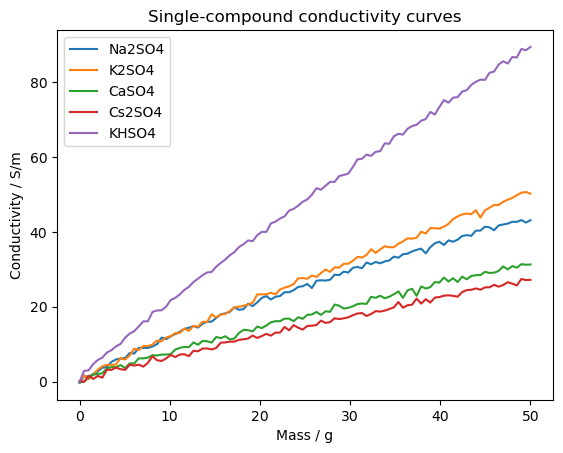

In [135]:
# plotting all conductivity curves at once 
for i in electrolyte_list:
    for ref in reference_curves:
        if ref["Component"] == i:
            plt.plot(m, ref["Kappa"], label=ref["Component"])
plt.title('Single-compound conductivity curves')
plt.xlabel('Mass / g')
plt.ylabel('Conductivity / S/m')
plt.legend()
plt.show()

In [136]:
# splitting the data to train and test
mixtures_train, mixtures_test = train_test_split(
    mixtures_sulf,
    test_size=0.2,
    random_state=42,
)
X_train = np.array([sample['Kappa_mix'] for sample in mixtures_train])
X_test = np.array([sample['Kappa_mix'] for sample in mixtures_test])
print(X_train.shape)
print(X_test.shape)

# fit PCA
pca_kappa_mix = PCA(k=2)
Z_mix_train = pca_kappa_mix.fit_transform(X_train)
Z_mix_test = pca_kappa_mix.transform(X_test)
print(Z_mix_train.shape)
print(Z_mix_test.shape)

(16, 100)
(4, 100)
(16, 2)
(4, 2)


In [137]:
correct = 0
correct_pca = 0

for unknown in mixtures_sulf:
    
    # without PCA
    pred_pair, w, error = identify_mixture(unknown['Kappa_mix'], use_pca=False)

    # with PCA
    pred_pair_pca, w_pca, error_pca = identify_mixture(unknown['Kappa_mix'], use_pca=True)

    actual_components = sorted(unknown['Components'])
    if sorted(pred_pair) == actual_components:
        correct += 1
    if sorted(pred_pair_pca) == actual_components:
        correct_pca += 1

    accuracy_ = correct / len(mixtures_sulf)
    accuracy_pca = correct_pca / len(mixtures_sulf)

    print('-' * 50)
    print('Predicted pair without PCA:', pred_pair)
    print('Predicted pair with PCA:', pred_pair_pca)
    print('Actual_components:', unknown['Components'])

    print('Predicted weights:', np.abs(w))
    print('Predicted weights with PCA:', np.abs(w_pca))
    print('Actual weights:', unknown['Weights'])
print('Original space accuracy:', accuracy_)
print('PCA space accuracy:', accuracy_pca)


--------------------------------------------------
Predicted pair without PCA: ('CaSO4', 'Cs2SO4')
Predicted pair with PCA: ('CaSO4', 'Cs2SO4')
Actual_components: ['CaSO4', 'Cs2SO4']
Predicted weights: [0.668 0.332]
Predicted weights with PCA: [0.668 0.332]
Actual weights: [0.69, 0.31]
--------------------------------------------------
Predicted pair without PCA: ('Na2SO4', 'KHSO4')
Predicted pair with PCA: ('Na2SO4', 'KHSO4')
Actual_components: ['KHSO4', 'Na2SO4']
Predicted weights: [0.284 0.716]
Predicted weights with PCA: [0.284 0.716]
Actual weights: [0.71, 0.29]
--------------------------------------------------
Predicted pair without PCA: ('Cs2SO4', 'KHSO4')
Predicted pair with PCA: ('K2SO4', 'KHSO4')
Actual_components: ['KHSO4', 'Cs2SO4']
Predicted weights: [0.32 0.68]
Predicted weights with PCA: [0.512 0.488]
Actual weights: [0.68, 0.32]
--------------------------------------------------
Predicted pair without PCA: ('Na2SO4', 'CaSO4')
Predicted pair with PCA: ('Na2SO4', 'Cs2SO4

## Results

### Curve Fitting and Optimization Performance
The data fitting demonstrated varying levels of efficiency across different concentrations. While the Kohlrausch linear model effectively maps low concentration behavior, its accuracy diminishes over wider concentration ranges. The global Lattey model, optimized via SciPy, outperformed the custom scaled RMSProp approach, succesfully capturing the data across varying temperatures. These curves output clean specific conductivity baseline signals ($\kappa$) against concentration ($c$ in g/kg).

### Singular Electrolyte Identification Comparison

| Metric / Feature | Minimum MSE Template Matching | One-vs-Rest Support Vector Machine (SVM) |
| :--- | :--- | :--- |
| **Overall Accuracy** | **Near Perfect (~99.6 %)** | **Significantly Lower / Inconsistent (~34 %)** |
| **Mathematical Nature** | Deterministic Global Comparison | Hyperplane Boundary Discrimination |
| **Handling of Noise** | Robust (Averages out over 100 points) | Highly Sensitive |
| **NaCl vs. KCl Resolution** | High (Captures subtle global deviations) | Poor (Fails due to lack of linear separability) |

#### 1. Why the MSE approach excels
The Minimum Mean Squared Error (MSE) template matching strategy yields near-perfect classification accuracy. By comparing an unknown, noisy curve vector $X_{\text{measured}}$ directly against the clean reference curves ($perfect\_curves$) derived from the global Lattey parameterization. Because the simulated Gaussian noise ($noise\_level = 1$) has a mean of zero, calculating the average squared residual over $100$ individual concentration steps effectively dampens out the noise:

$$\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(\kappa_{\text{measured}, i} - \kappa_{\text{reference}, i})^2 \approx \sigma_{\text{noise}}^2 + \text{Structural Mismatch}$$

#### 2. Why the SVM struggles
The linear Support Vector Machine (SVM) yields significantly lower accuracy, particularly when trying to isolate closely aligned species like $\text{NaCl}$ and $\text{KCl}$. This lower performance can be explained by several factors:
* The SVM treats the 100 points along the conductivity curve as completely independent, unlinked features in a 100-dimensional space. It fails to exploit the fact that these points belong to a smooth continuous physical function.
* The confusion matrix showed a systematic misclassification between chemically similar electrolytes. In particular, **K₂SO₄** and **KNO₃**, as well as **KCl** and **NaCl**, were frequently confused because their conductivity curves are highly similar over large concentration ranges.

### Identification of Two-Component Electrolyte Mixtures
The two mixture identification approaches, mean squared error (MSE) in the original conductivity space and MSE in the PCA-transformed space, achieved comparable overall performance. PCA did not provide a consistent improvement in identification accuracy over the original method. For some mixtures, both approaches correctly identified the electrolyte pair and the corresponding mixing ratio. However, there were also cases in which the original MSE approach correctly identified the mixture while the PCA-based approach predicted a different electrolyte pair. The performance of both methods strongly depended on the generated mixture set. Since the mixtures were created randomly, some test sets contained mixtures that were easier to distinguish than others. In particular, mixtures composed of electrolytes with clearly different conductivity curves were identified reliably by both methods, whereas mixtures containing electrolytes with similar conductivity behavior were much more difficult to distinguish. As a result, the measured accuracy varied depending on the selected test mixtures.
Several approximations were made during the development of the model.
* The investigated mixtures were restricted to weight ratios between 0.2 and 0.8 to exclude compositions such as 0.1/0.9, which were found to be more difficult to distinguish. 
* To identify the mixture compounds noise was added only to the unknown conductivity curve, while the reference curves were kept noise-free. Adding random noise to the reference curves would lead to different identification results for repeated calculations. 
* The selection of electrolytes was crucial for successful identification. Electrolytes with similar conductivity behavior produce overlapping conductivity curves, making it difficult or impossible to distinguish them, e.g. restricting the dataset to sulfates and hydrogensulfates  resulted in better identification performance compared to using the complete electrolyte set.
## Further Questions
Several extensions could improve the performance and applicability of the developed electrolyte identification model. 
* Electrolytes with strongly overlapping conductivity behavior could be excluded, while electrolytes with more distinct signatures would improve the reliability of the identification.
* The current model considers conductivity curves at a fixed temperature, while measurements at multiple temperatures could provide additional information and improve the distinction between electrolytes with similar conductivity behavior.
* Furthermore, more advanced machine learning approaches could be tested. Instead of comparing curves using mean squared error, methods such as neural networks or nearest-neighbor approaches could be trained directly on conductivity curves to identify components and their concentrations.
* Finally, the model could be extended from binary mixtures to mixtures containing more than two electrolytes. Although this would increase the complexity of the problem, it would make the approach more applicable to real experimental samples.